<a href="https://colab.research.google.com/github/lizethss2398/Proyecto-Apophis/blob/main/Apophis_Proy_LSS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto de aproximación de Apophis en abril de 2029
## Lizeth Serna Santa
### Curso de Mecánica Celeste - Universidad de Antioquia

En este proyecto se aplicarán los conceptos aprendidos en el curso de mecánica celeste alrededor de las temáticas de integración de N-cuerpos, dos cuerpos y 3 cuerpos circular restringido

In [1]:
!pip install -Uq pymcel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.9 MB/s eta 0:00:00


In [2]:
!pip install -Uq rebound

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 908.6/908.6 kB 22.1 MB/s eta 0:00:00


In [3]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
import spiceypy as spy
import rebound as rb
import pandas as pd

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


### Cálculo de la órbita de apophis a partir del problema de 2-cuerpos

In [4]:
# Elementos orbitales de Apophis obtenidos del small-body database
# Epoch: JD 2461000.5

a = 0.9223803173917017       # Semieje mayor [AU]
e = 0.191166355386932        # Excentricidad

i = np.radians(3.340958441017069)        # Inclinación [rad]
Omega = np.radians(203.8996515621043)    # Nodo ascendente [rad]
omega = np.radians(126.6728325163065)    # Argumento del perihelio [rad]

M0 = np.radians(312.8054663584516)       # Anomalía media inicial [rad]

# Movimiento medio
n_deg_day = 1.11259994308075
n = np.radians(n_deg_day)                # [rad/day]

# Periodo orbital
T = 323.5664375491271                    # [days]


dt = 0.5                                 # Paso temporal [days]

t = np.arange(0, 2*T, dt)                # Simulación de 2 órbitas

In [5]:
# Anomalía media

M = M0 + n*t

# Reducimos al intervalo [0, 2pi]

M = np.mod(M, 2*np.pi)


# Resolución de la ecuación de Kepler con método de Newton-Raphson

def kepler(M, e, tol=1e-10):

    E = M.copy()

    for _ in range(100):

        f = E - e*np.sin(E) - M
        fp = 1 - e*np.cos(E)

        dE = -f/fp

        E += dE

        if np.max(np.abs(dE)) < tol:
            break

    return E

# Anomalía excéntrica

E = kepler(M, e)

# Anomalía verdadera

f = 2*np.arctan2(
    np.sqrt(1+e)*np.sin(E/2),
    np.sqrt(1-e)*np.cos(E/2)
)


# Distancia radial


r = a*(1 - e*np.cos(E))

In [6]:
# Coordenadas en el plano orbital

x_orb = r*np.cos(f)
y_orb = r*np.sin(f)

# Transformación al sistema heliocéntrico eclíptico

x = (
    (np.cos(Omega)*np.cos(omega)
     - np.sin(Omega)*np.sin(omega)*np.cos(i))*x_orb
    +
    (-np.cos(Omega)*np.sin(omega)
     - np.sin(Omega)*np.cos(omega)*np.cos(i))*y_orb
)

y = (
    (np.sin(Omega)*np.cos(omega)
     + np.cos(Omega)*np.sin(omega)*np.cos(i))*x_orb
    +
    (-np.sin(Omega)*np.sin(omega)
     + np.cos(Omega)*np.cos(omega)*np.cos(i))*y_orb
)

z = (
    (np.sin(omega)*np.sin(i))*x_orb
    +
    (np.cos(omega)*np.sin(i))*y_orb
)

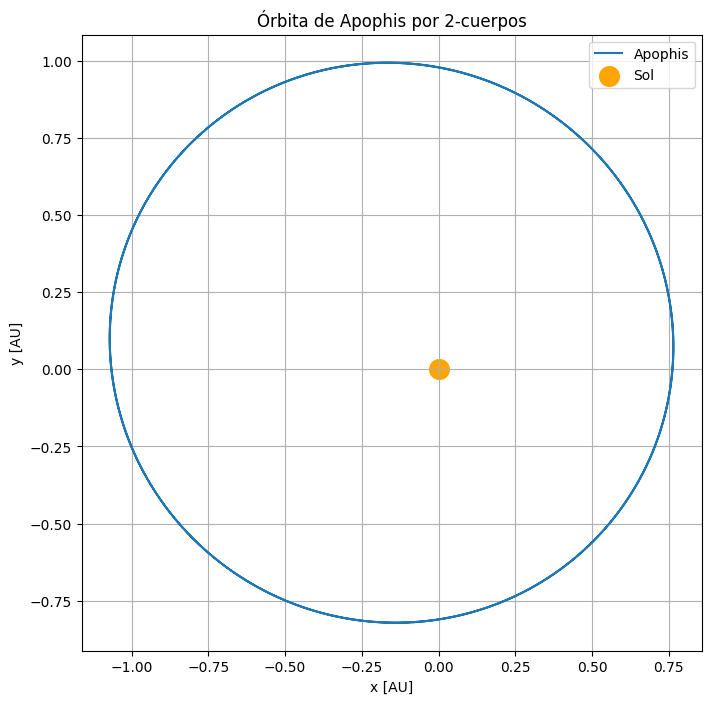

In [7]:
# Gráfica de la orbita

plt.figure(figsize=(8,8))

plt.plot(x, y, linewidth=1.5, label='Apophis')

plt.scatter(0, 0,
            color='orange',
            s=200,
            label='Sol')

plt.xlabel('x [AU]')
plt.ylabel('y [AU]')

plt.title('Órbita de Apophis por 2-cuerpos')

plt.axis('equal')

plt.grid()
plt.legend()

plt.show()

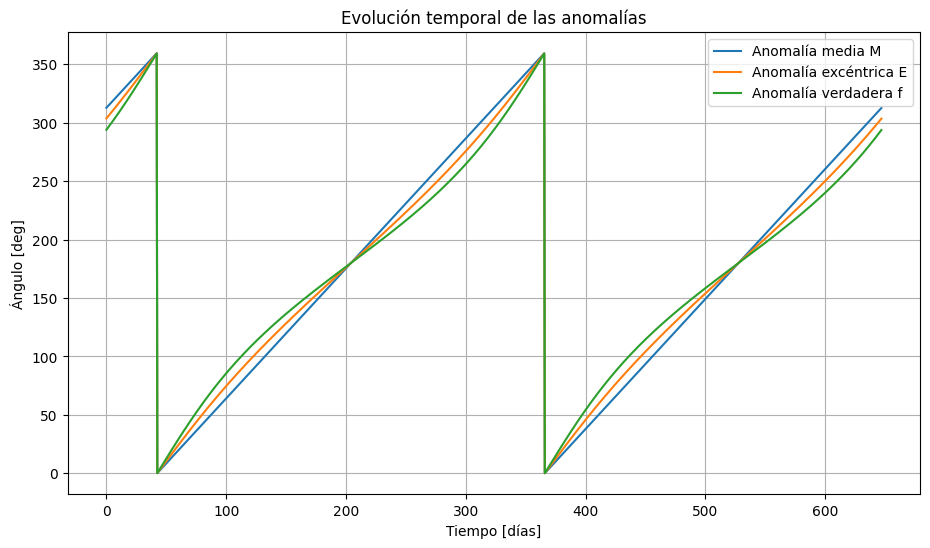

In [8]:
#Gráfica anomalías

plt.figure(figsize=(11,6))

plt.plot(t,
         np.degrees(M),
         label='Anomalía media M')

plt.plot(t,
         np.degrees(E),
         label='Anomalía excéntrica E')

plt.plot(t,
         np.degrees(f),
         label='Anomalía verdadera f')

plt.xlabel('Tiempo [días]')
plt.ylabel('Ángulo [deg]')

plt.title('Evolución temporal de las anomalías')

plt.grid()
plt.legend()

plt.show()

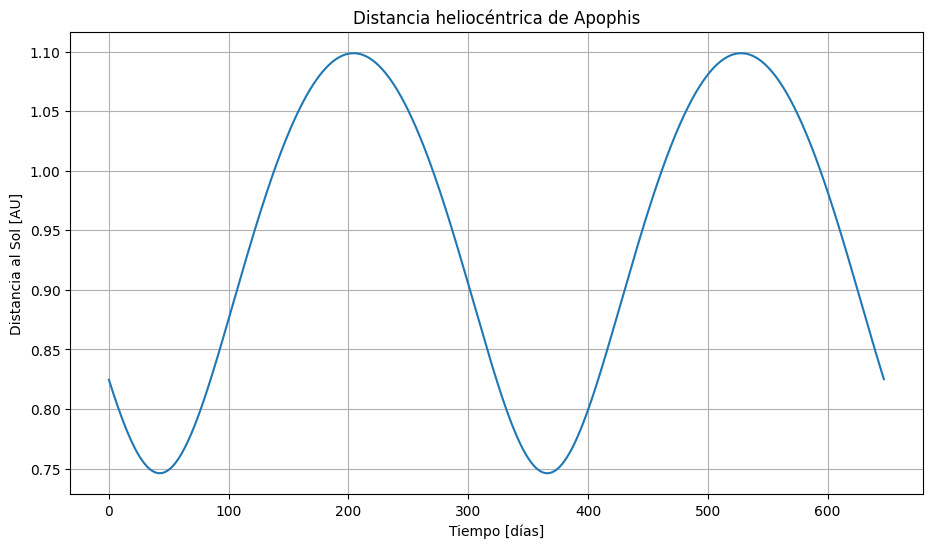

In [9]:
#Distancia apophis-sol
plt.figure(figsize=(11,6))

plt.plot(t, r)

plt.xlabel('Tiempo [días]')
plt.ylabel('Distancia al Sol [AU]')

plt.title('Distancia heliocéntrica de Apophis')

plt.grid()

plt.show()

## Problema N- cuerpos con la Tierra el sol y Apophis

In [10]:
#Definición de unidades

M_sol = pc.constantes.M_sun # kg
AU = pc.constantes.au # m
año = pc.constantes.año # s

UM = M_sol # Masas solares          -> Unidad de masa
UL = AU    # Unidades astronómicas  -> Unidad de longitud
UT = año   # segundos en un año     -> Unidad de tiempo

UV = UL/UT      #  -> Unidad de velocidad
UA = UV/UT      #  -> Unidad de aceleración

In [11]:
# Crear simulación
sim = rb.Simulation()

# Unidades:AU, días, masas solares
sim.units = ('AU', 'days', 'Msun')

# Integrador
sim.integrator = "ias15"

# Masas
M_sun = 1.0
M_earth = 3.003e-6
M_apophis = 3.07e-20

sim.add(m=M_sun)

# Elementos orbitales aproximados de la Tierra
sim.add(
    m=M_earth,

    a=1.00000011,
    e=0.01671022,

    inc=np.radians(0.00005),

    Omega=np.radians(-11.26064),
    omega=np.radians(102.94719),

    M=np.radians(100.46435)
)

# Elementos orbitales de Apophis
# Epoch: JD 2461000.5

sim.add(
    m=M_apophis,

    a=0.9223803173917017,
    e=0.191166355386932,

    inc=np.radians(3.340958441017069),

    Omega=np.radians(203.8996515621043),
    omega=np.radians(126.6728325163065),

    M=np.radians(312.8054663584516)
)


sim.move_to_com()

print(sim)

<rebound.simulation.Simulation object at 0x7a2f327545c0, N=3, t=0.0>


In [12]:
# Simulación de 3 años
years = 3
tmax = years*365.25

N = 5000

times = np.linspace(0, tmax, N)

# Arreglos

x_earth = np.zeros(N)
y_earth = np.zeros(N)

x_apophis = np.zeros(N)
y_apophis = np.zeros(N)

dist = np.zeros(N)

# Integración
for i, time in enumerate(times):

    sim.integrate(time)

    earth = sim.particles[1]
    apophis = sim.particles[2]

    # Tierra
    x_earth[i] = earth.x
    y_earth[i] = earth.y

    # Apophis
    x_apophis[i] = apophis.x
    y_apophis[i] = apophis.y

    # Distancia entre ambos

    dx = apophis.x - earth.x
    dy = apophis.y - earth.y
    dz = apophis.z - earth.z

    dist[i] = np.sqrt(dx**2 + dy**2 + dz**2)

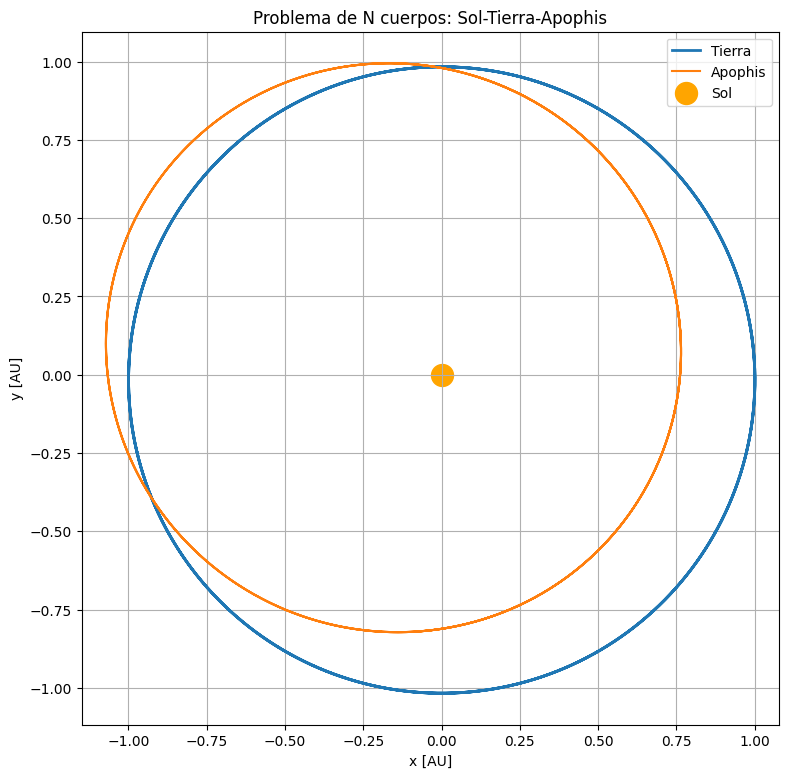

In [13]:
plt.figure(figsize=(9,9))
# Órbita Tierra
plt.plot(
    x_earth,
    y_earth,
    label='Tierra',
    linewidth=2
)

# Órbita Apophis
plt.plot(
    x_apophis,
    y_apophis,
    label='Apophis',
    linewidth=1.5
)

# Sol
plt.scatter(
    0,
    0,
    color='orange',
    s=250,
    label='Sol'
)

plt.xlabel('x [AU]')
plt.ylabel('y [AU]')

plt.title('Problema de N cuerpos: Sol-Tierra-Apophis')

plt.axis('equal')

plt.grid()
plt.legend()

plt.show()

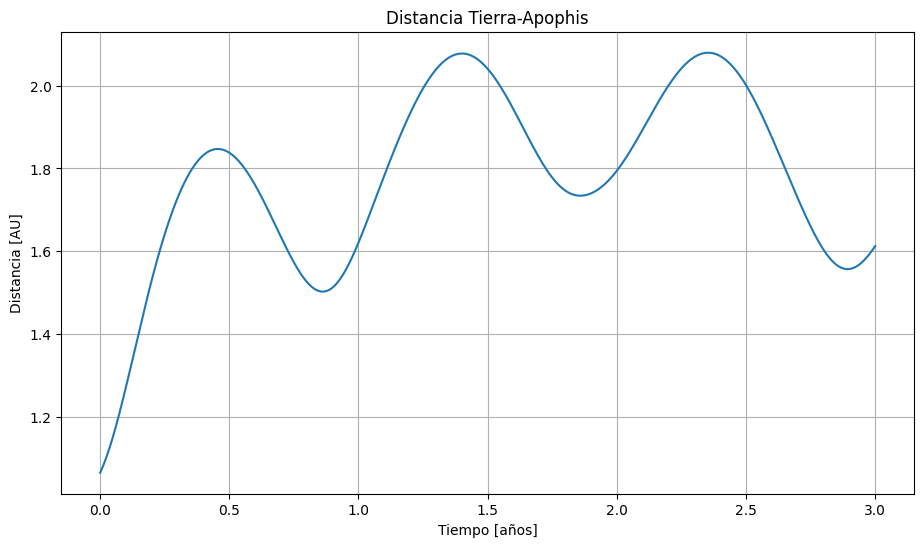

In [14]:
# Distancia Tierra - Apophis

plt.figure(figsize=(11,6))

plt.plot(times/365.25, dist)

plt.xlabel('Tiempo [años]')
plt.ylabel('Distancia [AU]')

plt.title('Distancia Tierra-Apophis')

plt.grid()

plt.show()

## Problema N cuerpos con los 8 planetas del sistema solar

In [15]:
from scipy.integrate import odeint, solve_ivp
import time
from astropy.time import Time
from datetime import timedelta
from astropy import units as u


In [16]:
# configuración inicial

# nombres de los objetos
cuerpos = [
    'Sol', 'Mercurio', 'Venus', 'Tierra',
    'Marte', 'Júpiter', 'Saturno',
    'Urano', 'Neptuno', 'Apophis'
]

#id de horizons

ids = [
    '10', '199', '299', '399',
    '499', '599', '699',
    '799', '899', '99942'
]

# fecha inicial

fecha_inicio = "2026-05-12 00:00:00"

# creación de la simulación

sim = rb.Simulation()

sim.units = ('Msun', 'AU', 'day')

sim.integrator = "ias15"

In [17]:
# construcción del sistema solar

for body_id in ids:

    sim.add(body_id, date=fecha_inicio)

# mover al centro de masa

sim.move_to_com()

print(sim)

Searching NASA Horizons for '10'... 
Found: Sun (10) 
Searching NASA Horizons for '199'... 
Found: Mercury (199) 
Searching NASA Horizons for '299'... 
Found: Venus (299) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '499'... 
Found: Mars (499) 
Searching NASA Horizons for '599'... 
Found: Jupiter (599) 
Searching NASA Horizons for '699'... 
Found: Saturn (699) 
Searching NASA Horizons for '799'... 
Found: Uranus (799) 
Searching NASA Horizons for '899'... 
Found: Neptune (899) 
Searching NASA Horizons for '99942'... 
Found: 99942 Apophis (2004 MN4) 
<rebound.simulation.Simulation object at 0x7a2f327573d0, N=10, t=0.0>


/usr/local/lib/python3.12/dist-packages/rebound/horizons.py:184: RuntimeWarning: Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.
  warnings.warn("Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.", RuntimeWarning)


In [18]:
# integración temporal

dias_totales = 1500 # tiempo total de simulación
dt = 0.5 # paso temporal
tiempos = np.arange(0, dias_totales, dt) # arreglo temporal

# arreglos para almacenar trayectorias
trayectorias_x = []
trayectorias_y = []
trayectorias_z = []

for _ in cuerpos:
    trayectorias_x.append([])
    trayectorias_y.append([])
    trayectorias_z.append([])

distancias = [] # distancia tierra-apophis

# integración

for t in tiempos:
    sim.integrate(t)

    for j in range(len(cuerpos)):
        p = sim.particles[j]

        trayectorias_x[j].append(p.x)
        trayectorias_y[j].append(p.y)
        trayectorias_z[j].append(p.z)

    tierra = sim.particles[3]
    apophis = sim.particles[9]

    # distancia relativa

    dx = apophis.x - tierra.x
    dy = apophis.y - tierra.y
    dz = apophis.z - tierra.z

    d = np.sqrt(dx**2 + dy**2 + dz**2)

    distancias.append(d)

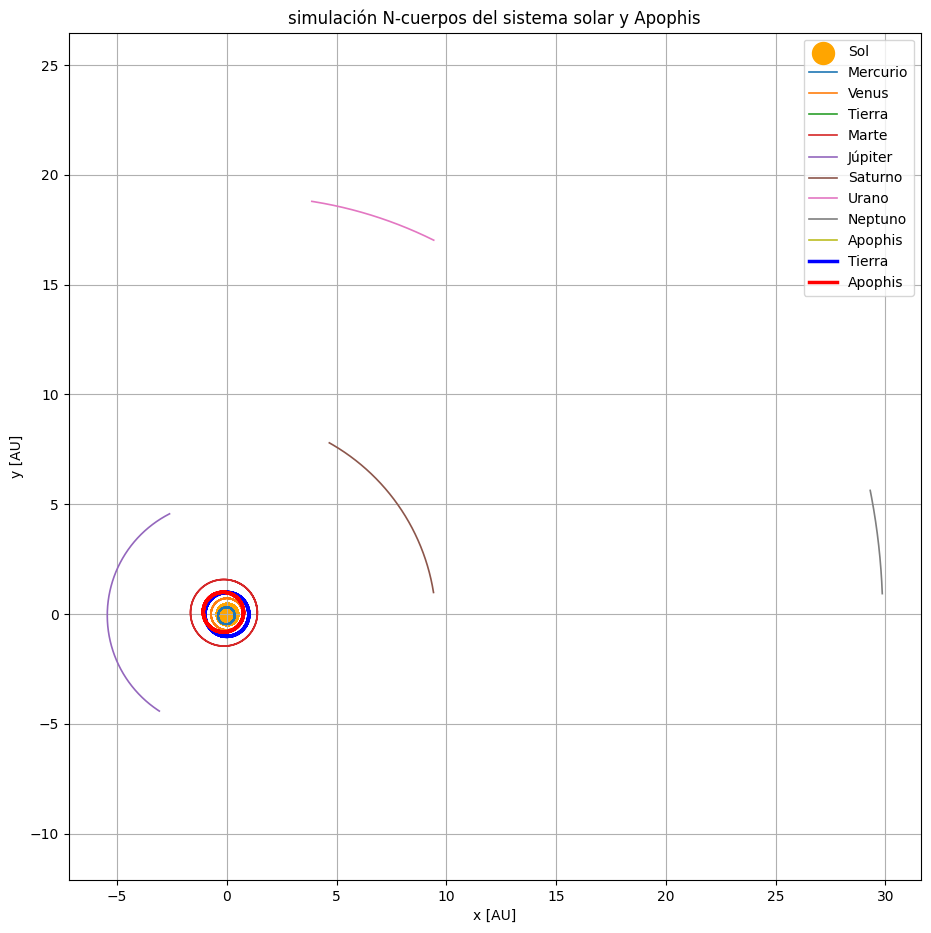

In [19]:
# órbitas
from mpl_toolkits.mplot3d import Axes3D
plt.figure(figsize=(11,11))

for j in range(len(cuerpos)):

    # para que las órbitas internas no queden ocultas
    if cuerpos[j] == 'Sol':

        plt.scatter(
            trayectorias_x[j],
            trayectorias_y[j],
            s=250,
            color='orange',
            label='Sol'
        )

    else:

        plt.plot(
            trayectorias_x[j],
            trayectorias_y[j],
            linewidth=1.2,
            label=cuerpos[j]
        )

# órbita de la Tierra resaltada

plt.plot(
    trayectorias_x[3],
    trayectorias_y[3],
    linewidth=2.5,
    color='blue',
    label='Tierra'
)

# órbita de Apophis resaltada

plt.plot(
    trayectorias_x[9],
    trayectorias_y[9],
    linewidth=2.5,
    color='red',
    label='Apophis'
)

plt.xlabel('x [AU]')
plt.ylabel('y [AU]')

plt.title('simulación N-cuerpos del sistema solar y Apophis')

plt.axis('equal')

plt.grid()
plt.legend()

plt.show()

In [20]:
# gráfica 3D interactiva con plotly
import plotly.graph_objects as go
fig = go.Figure()

colores = {
    'Mercurio': 'gray',
    'Venus': 'orange',
    'Tierra': 'blue',
    'Marte': 'red',
    'Júpiter': 'brown',
    'Saturno': 'gold',
    'Urano': 'cyan',
    'Neptuno': 'purple',
    'Apophis': 'black'
}
# agregar órbitas

for j in range(len(cuerpos)):
    nombre = cuerpos[j]
    # Sol
    if nombre == 'Sol':
        fig.add_trace(
            go.Scatter3d(
                x=trayectorias_x[j],
                y=trayectorias_y[j],
                z=trayectorias_z[j],
                mode='markers',
                marker=dict(
                    size=5,
                    color='yellow'
                ),
                name='Sol'
            )
        )

    # Tierra y Apophis resaltados
    elif nombre == 'Tierra':
        fig.add_trace(
            go.Scatter3d(
                x=trayectorias_x[j],
                y=trayectorias_y[j],
                z=trayectorias_z[j],
                mode='lines',
                line=dict(
                    color='blue',
                    width=6
                ),
                name='Tierra'
            )
        )

    elif nombre == 'Apophis':
        fig.add_trace(
            go.Scatter3d(
                x=trayectorias_x[j],
                y=trayectorias_y[j],
                z=trayectorias_z[j],
                mode='lines',
                line=dict(
                    color='black',
                    width=6
                ),

                name='Apophis'
            )
        )

    # demás planetas
    else:
        fig.add_trace(
            go.Scatter3d(
                x=trayectorias_x[j],
                y=trayectorias_y[j],
                z=trayectorias_z[j],
                mode='lines',
                line=dict(
                    color=colores.get(nombre, 'white'),
                    width=3
                ),
                name=nombre
            )
        )


# configuración de cámara y ejes
fig.update_layout(
    title='órbitas 3D del sistema solar y Apophis',
    scene=dict(
        xaxis_title='x [AU]',
        yaxis_title='y [AU]',
        zaxis_title='z [AU]',
        aspectmode='data',
        camera=dict(
            eye=dict(
                x=0,
                y=0,
                z=1.8
            )
        )
    ),

    width=1000,
    height=900
)
fig.show()

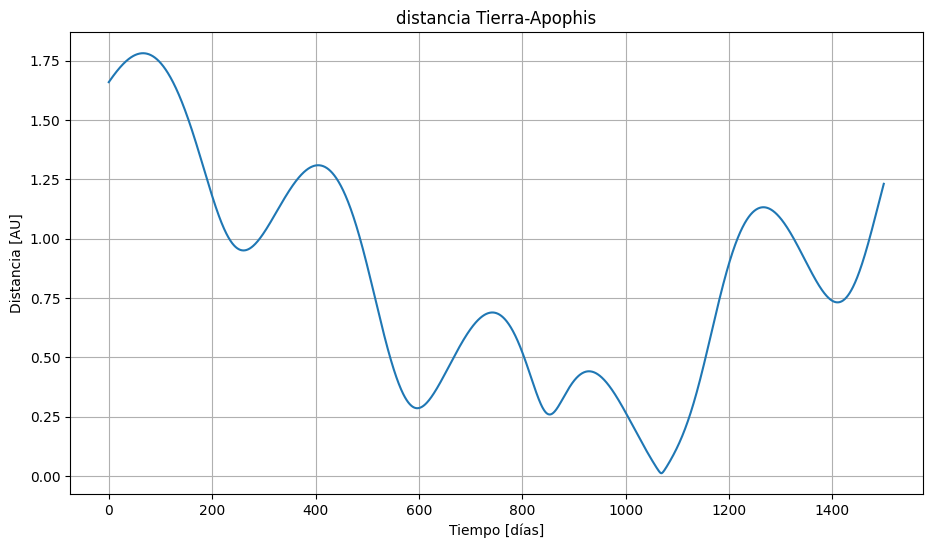

In [21]:
# distancia tierra-apophis
plt.figure(figsize=(11,6))
plt.plot(tiempos, distancias)

plt.xlabel('Tiempo [días]')
plt.ylabel('Distancia [AU]')

plt.title('distancia Tierra-Apophis')
plt.grid()
plt.show()

In [22]:
# máxima aproximación
# distancia mínima
dist_min = np.min(distancias)

# índice del mínimo
indice_min = np.argmin(distancias)

# tiempo correspondiente
t_min = tiempos[indice_min]

# fecha inicial
fecha0 = Time(fecha_inicio, scale='utc')

# fecha de máxima aproximación
fecha_aprox = fecha0 + t_min*u.day

# resultados

print(f"Distancia mínima Tierra-Apophis: {dist_min:.6f} AU")
print(f"Tiempo desde el inicio: {t_min:.2f} días")
print(f"Máxima aproximación UTC: {fecha_aprox.iso}")

Distancia mínima Tierra-Apophis: 0.011532 AU
Tiempo desde el inicio: 1069.00 días
Máxima aproximación UTC: 2029-04-15 00:00:00.000


/usr/local/lib/python3.12/dist-packages/erfa/core.py:133: ErfaWarning:

ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"

/usr/local/lib/python3.12/dist-packages/erfa/core.py:133: ErfaWarning:

ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"



## Problema 3 cuerpos restringido

In [23]:
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve

In [24]:
# parámetros físicos del sistema

# masas
Msol = 1.0
Mtierra = 3.003489e-6

# parámetro alfa
alpha = Mtierra / (Msol + Mtierra)

print(alpha)

3.0034799790809213e-06


In [25]:
# fecha de estudio
fecha = "2029-04-10 00:00:00"

In [26]:
# consulta de elementos orbitales reales de Apophis

tabla, ts, datos = pc.consulta_horizons(
    id='99942',
    location='@10',
    epochs=fecha,
    datos='elements',
    propiedades='default'
)

print(tabla)

/usr/local/lib/python3.12/dist-packages/erfa/core.py:133: ErfaWarning:

ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"



       targetname        datetime_jd ...         Q                 P        
          ---                 d      ...         AU                d        
------------------------ ----------- ... ----------------- -----------------
99942 Apophis (2004 MN4)   2462236.5 ... 1.099198404475986 323.3222380583385


In [27]:
# extracción de elementos orbitales

a = tabla['a'][0]
e = tabla['e'][0]
inc = np.deg2rad(tabla['incl'][0])
Omega = np.deg2rad(tabla['Omega'][0])
omega = np.deg2rad(tabla['w'][0])
M = np.deg2rad(tabla['M'][0])

print(a,e)

0.9219161713005533 0.1922975631562459


In [28]:
# resolución de la ecuación de Kepler
def kepler(E):
    return E - e*np.sin(E) - M

# anomalía excéntrica

E = fsolve(kepler, M)[0]

# anomalía verdadera

f = 2*np.arctan2(

    np.sqrt(1+e)*np.sin(E/2),

    np.sqrt(1-e)*np.cos(E/2)
)

print(f)

4.009017915763227


In [29]:
# posición y velocidad en el plano orbital

# distancia orbital
r = a*(1-e**2)/(1+e*np.cos(f))

# coordenadas perifocales
x_orb = r*np.cos(f)
y_orb = r*np.sin(f)

# parámetro gravitacional normalizado
mu_sol = 1.0

h = np.sqrt(mu_sol*a*(1-e**2))

# velocidades perifocales
vx_orb = -(mu_sol/h)*np.sin(f)

vy_orb = (mu_sol/h)*(e + np.cos(f))

In [30]:
# rotación al sistema heliocéntrico

# matrices de rotación

R3_Omega = np.array([

    [ np.cos(Omega), -np.sin(Omega), 0],
    [ np.sin(Omega),  np.cos(Omega), 0],
    [0,0,1]
])

R1_i = np.array([

    [1,0,0],
    [0,np.cos(inc),-np.sin(inc)],
    [0,np.sin(inc), np.cos(inc)]
])

R3_omega = np.array([

    [ np.cos(omega), -np.sin(omega), 0],
    [ np.sin(omega),  np.cos(omega), 0],
    [0,0,1]
])

# matriz total

Rot = R3_Omega @ R1_i @ R3_omega

# posición heliocéntrica

r_pf = np.array([x_orb, y_orb, 0])

r_helio = Rot @ r_pf

# velocidad heliocéntrica

v_pf = np.array([vx_orb, vy_orb, 0])

v_helio = Rot @ v_pf

In [31]:
# transformación al sistema rotante del CR3BP

# Tierra en el eje x
theta = np.arctan2(r_helio[1], r_helio[0])

c = np.cos(-theta)
s = np.sin(-theta)

Rot2 = np.array([

    [c,-s],
    [s, c]
])

# posición rotante
r_rot = Rot2 @ r_helio[:2]

# velocidad angular normalizada
n = 1.0
omega_vec = np.array([0,0,n])

# corrección por marco rotante
cor = np.cross(
    omega_vec,
    np.array([r_helio[0],r_helio[1],0])
)

v_rot = Rot2 @ (v_helio[:2] - cor[:2])


# normalización
# distancia Tierra-Sol = 1

x0 = r_rot[0]
y0 = r_rot[1]

vx0 = v_rot[0]
vy0 = v_rot[1]

Y0 = [x0,y0,vx0,vy0]

print(Y0)

[np.float64(1.0139282997504908), np.float64(6.133232907247858e-17), np.float64(-0.1554494936382134), np.float64(-0.08622469072354863)]


In [32]:
# ecuaciones del CR3BP

def cr3bp(t,Y):

    x,y,vx,vy = Y

    r1 = np.sqrt((x+alpha)**2 + y**2)

    r2 = np.sqrt((x-(1-alpha))**2 + y**2)

    dUdx = (

        x

        - (1-alpha)*(x+alpha)/(r1**3)

        - alpha*(x-(1-alpha))/(r2**3)
    )

    dUdy = (

        y

        - (1-alpha)*y/(r1**3)

        - alpha*y/(r2**3)
    )

    ax = 2*vy + dUdx

    ay = -2*vx + dUdy

    return [vx,vy,ax,ay]

In [33]:
# integración temporal

t0 = 0

tf = 8*np.pi

N = 25000

t_eval = np.linspace(t0,tf,N)

sol = solve_ivp(

    cr3bp,

    [t0,tf],

    Y0,

    t_eval=t_eval,

    rtol=1e-10,

    atol=1e-10
)

In [34]:
# solución
x = sol.y[0]
y = sol.y[1]

In [35]:
# puntos de lagrange

rhill = (alpha/3)**(1/3)

L1 = [1-rhill,0]

L2 = [1+rhill,0]

L3 = [-1-(5*alpha/12),0]

L4 = [0.5-alpha, np.sqrt(3)/2]

L5 = [0.5-alpha,-np.sqrt(3)/2]

In [36]:
# distancia Tierra-Apophis

distancias = np.sqrt(

    (x-(1-alpha))**2 +
    y**2
)

indice_min = np.argmin(distancias)

dmin = distancias[indice_min]

print(dmin)

0.005832098280722209


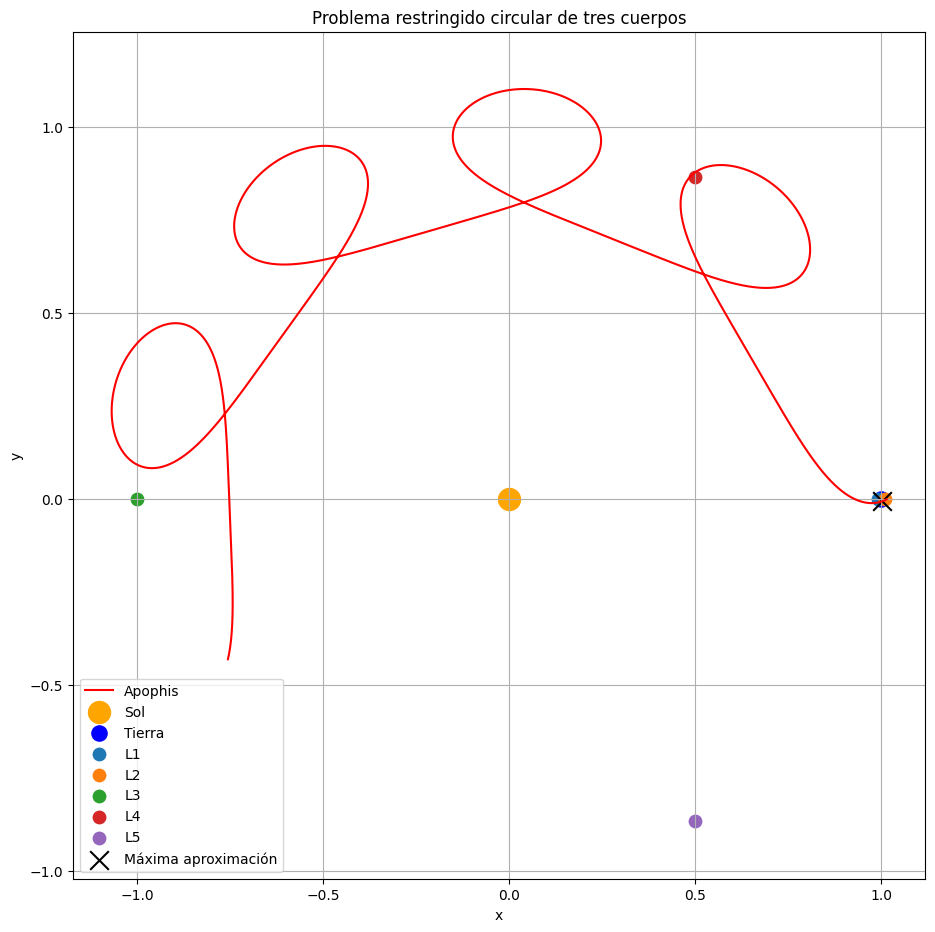

In [37]:
# gráfica final

plt.figure(figsize=(11,11))

# trayectoria de Apophis

plt.plot(

    x,
    y,

    color='red',

    linewidth=1.5,

    label='Apophis'
)

# Sol

plt.scatter(

    -alpha,
    0,

    s=250,

    color='orange',

    label='Sol'
)

# Tierra

plt.scatter(

    1-alpha,
    0,

    s=120,

    color='blue',

    label='Tierra'
)

# puntos de lagrange

plt.scatter(*L1,s=80,label='L1')
plt.scatter(*L2,s=80,label='L2')
plt.scatter(*L3,s=80,label='L3')

plt.scatter(*L4,s=80,label='L4')
plt.scatter(*L5,s=80,label='L5')

# máxima aproximación

plt.scatter(

    x[indice_min],
    y[indice_min],

    s=180,

    color='black',

    marker='x',

    label='Máxima aproximación'
)

plt.xlabel('x')

plt.ylabel('y')

plt.title('Problema restringido circular de tres cuerpos')

plt.axis('equal')

plt.grid()

plt.legend()

plt.show()

## Calculo de la anomalía excentrica de Apophis el día de máxima aproximación con la Tierra

In [38]:
deg = np.pi/180

In [39]:
#Consultamos los parámetros orbitales de apophis en el jpl small body database
e = 0.1911663355386932 #Excentricidad orbital y magnitud del vector de Laplace
a =	0.9223803173917017	* pc.constantes.au #Semi eje mayor
q	= 0.7460522521429133 * pc.constantes.au
i	= 3.340958441017069	* deg #Inclinación orbital
node =	203.8996515621043	* deg #Nodo ascendente
peri =	126.6728325163065	* deg #Periapsis
tp	= 2461042.918242006079 * 86400 #fecha juliana
mu = pc.constantes.mu_sun #mu del sistema, en este caso del sistema solar

In [40]:
#Variables derivadas
h = np.sqrt(mu * a * (1-e**2))
b = a * np.sqrt(1-e**2)

h,b

(np.float64(4200387442699322.5), np.float64(135441343761.16716))

In [41]:
from astropy.time import Time

In [42]:
t = Time("2029-04-13 18:52:00", scale = 'tdb').jd * 86400
t

np.float64(212737560720.0)

In [43]:
#Escribir la ecuación en la forma f(E)=0
def ecuacion_kepler(E):
  funcion = E - e  * np.sin(E) - h/(a*b)*(t-tp)
  return funcion

In [44]:
#Resolver la ecuación de Kepler:
from scipy.optimize import newton

In [45]:
E = newton(ecuacion_kepler,0) #Anomalía excentrica el dia del paso más cercano
E

np.float64(23.081594014937842)

In [46]:
tabla, jd, X = pc.consulta_horizons(
    id = 'Apophis',
    location = '@SSB',
    epochs = dict(start='2026-04-20',stop='2032-04-20', step ='180d')
)
X = np.array(X)
X

array([[-4.54615645e+10,  1.46498906e+11, -8.91205586e+09,
        -2.72244445e+04, -4.00763765e+03, -4.30333986e+02],
       [ 7.30494894e+09, -1.20742879e+11,  6.59475016e+09,
         3.45068014e+04,  7.26012715e+03,  4.28163844e+02],
       [-1.19047091e+11,  1.10721639e+11, -8.74936147e+09,
        -1.86353812e+04, -1.77744955e+04,  5.08159324e+02],
       [ 9.80036049e+10, -5.38450039e+10,  5.16772868e+09,
         1.81150024e+04,  3.29746582e+04, -1.33181089e+03],
       [-1.57406400e+11,  4.14781172e+10, -5.95425460e+09,
        -5.19153648e+03, -2.52236666e+04,  1.22416011e+03],
       [ 1.05977605e+11,  5.80733685e+10, -6.10196911e+08,
        -1.22722060e+04,  3.28782023e+04, -2.04493952e+03],
       [-1.48602374e+11, -3.98094908e+10, -1.38934227e+09,
         1.10895524e+04, -2.52123119e+04,  1.61169659e+03],
       [ 1.50962142e+11,  8.33129248e+10, -6.19057985e+08,
        -8.52459732e+03,  2.57424134e+04, -1.04695961e+03],
       [-1.45943637e+11,  1.08493998e+11, -6.109

In [47]:
rvec = X[:,:3]
#r = np.linalg.norm(rvec[:], )
vvec = X[:,3:]
#v = np.linalg.norm(vvec)
#Vector de Laplace
mu = pc.constantes.mu_sun #aproximacion
print(len(rvec))
print(len(vvec))


13
13


Determinaciónd de elementos orbitales $(p,e,I,\Omega,\omega,f)$

In [48]:
def calculate_orbital_elements(rvec, vvec, mu):
    """
    Calcula los seis elementos orbitales clásicos a partir de los vectores de posición y velocidad.

    Args:
        rvec (np.ndarray): Vector de posición (x, y, z).
        vvec (np.ndarray): Vector de velocidad (vx, vy, vz).
        mu (float): Parámetro gravitacional estándar del cuerpo central.

    Returns:
        tuple: (p, e, I, Omega, omega, f)
            p (float): Semilatus rectum.
            e (float): Excentricidad.
            I (float): Inclinación (radianes).
            Omega (float): Longitud del nodo ascendente (radianes).
            omega (float): Argumento del periapsis (radianes).
            f (float): Anomalía verdadera (radianes).
    """
    r = np.linalg.norm(rvec)
    v = np.linalg.norm(vvec)

    # Momento angular específico (h)
    hvec = np.cross(rvec, vvec)
    h = np.linalg.norm(hvec)

    # Semilatus rectum (p)
    p = h**2 / mu

    # Vector de excentricidad (evec)
    evec = (np.cross(vvec, hvec) / mu) - (rvec / r)
    e = np.linalg.norm(evec)

    # Inclinación (I)
    I = np.arccos(hvec[2] / h)

    # Vector de nodos (nvec)
    nvec = np.cross([0, 0, 1], hvec) # Nodo ascendente en el plano XY
    n = np.linalg.norm(nvec)

    # Longitud del nodo ascendente (Omega)
    if n == 0:
        Omega = 0.0 # Órbita ecuatorial, Omega no definido, se toma 0
    else:
        Omegap = np.arccos(nvec[0] / n) # Cosine of angle with +X axis
        if nvec[1] >= 0:
            Omega = Omegap
        else:
            Omega = 2 * np.pi - Omegap

    # Argumento del periapsis (omega)
    if e == 0:
        omega = 0.0 # Órbita circular, omega no definido, se toma 0
    elif n == 0:
        omega = np.arccos(evec[0] / e) # Si órbita ecuatorial, se mide desde +X
        if evec[1] < 0: # Check y-component of evec
            omega = 2 * np.pi - omega
    else:
        omegap = np.arccos(np.dot(nvec, evec) / (n * e))
        if evec[2] >= 0: # Check z-component of evec
            omega = omegap
        else:
            omega = 2 * np.pi - omegap

    # Anomalía verdadera (f)
    if e == 0:
        f = np.arccos(np.dot(rvec, evec) / (r * e)) if e != 0 else np.arccos(rvec[0]/r)
        if np.dot(rvec, vvec) < 0:
            f = 2 * np.pi - f
    else:
        fp = np.arccos(np.dot(evec, rvec) / (e * r))
        if np.dot(rvec, vvec) >= 0:
            f = fp
        else:
            f = 2 * np.pi - fp

    return p, e, I, Omega, omega, f

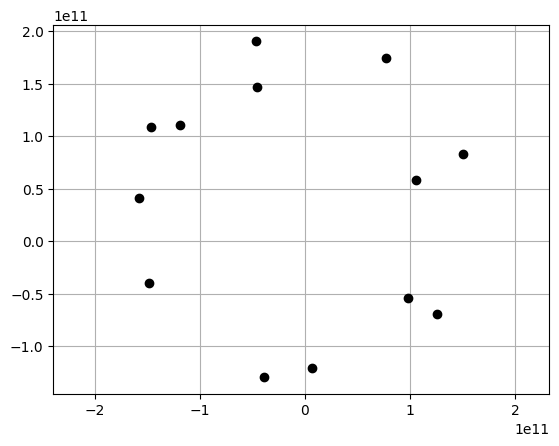

In [49]:
Es = np.zeros((len(jd),6))

for i, jd in enumerate(jd):
  rvec = X[i,:3]
  vvec = X[i, 3:]
  p, e, I, Omega, omega, f = calculate_orbital_elements(rvec, vvec, mu)
  Es[i] = p, e, I, Omega, omega, f

  plt.plot(rvec[0],rvec[1],'ko')

plt.axis('equal')
plt.grid()